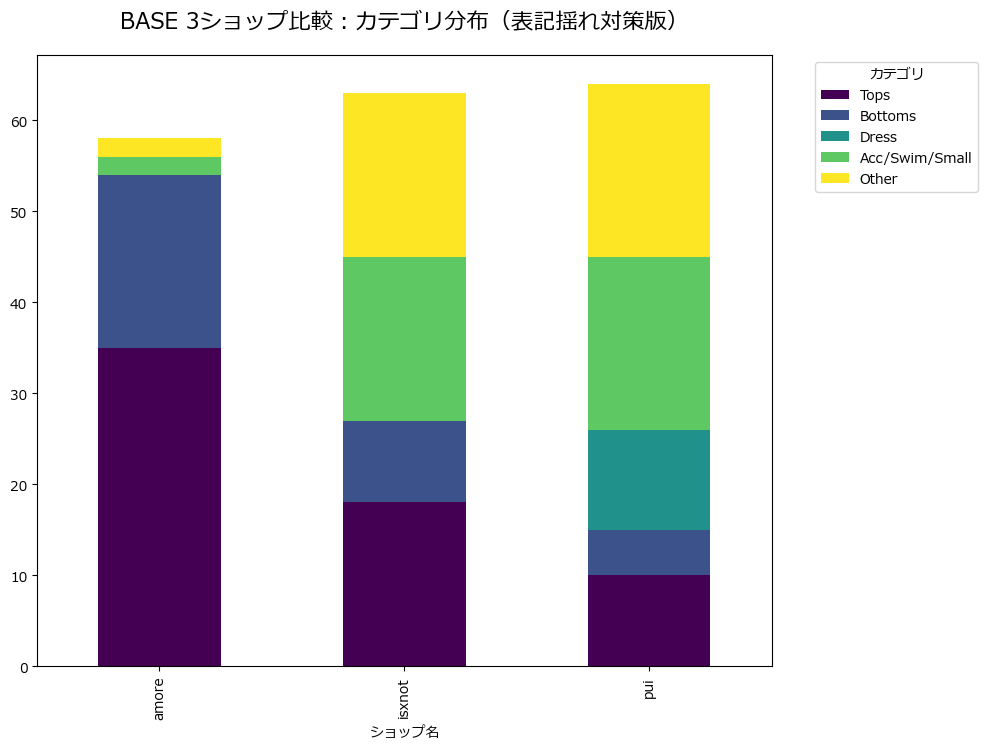

分析対象数: 185件
▼ まだ'Other'に残っている商品
['RIBBON KNIT', 'flower peplum one piece', 'gingham peplum one piece', 'rose peplum one-piece', 'Heart peplum one piece', 'lace camisole', 'THE ROSE BALM', 'PUI BORDER NEVY', 'FLOWRE SETUP', 'red dot one-piece', 'dot one-piece', 'CASHMERE KNIT', 'ボーダートップス', 'flower shirt one-piece', 'FLOWER ENSEMBLE', 'PUI KIDS HEART ONE PIECE', 'ROSE DE DAMAS アロマティックナチュレソープ', 'HOTEL BENOITE SWEAT', 'NOVELTY (THE SUNDAY ROMANTIC)', 'CHECK shirt', 'Rib Knit', '【サンプル発売】flap shirt', 'ポストカード', 'shelter outer', 'Cookie snood', 'サンドビーニー / NRK 26summer']


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. データの読み込み
df = pd.read_csv("combined_base_data.csv")

# 【最重要】表記揺れを徹底的に潰す「クレンジング関数」
def clean_text(text):
    import unicodedata
    # ① 全角を半角に統一（normalize）
    text = unicodedata.normalize('NFKC', str(text))
    # ② 2個以上の連続する空白を1つの半角スペースにまとめる
    text = re.sub(r'\s+', ' ', text)
    # ③ 前後の余計な空白を消す
    return text.strip()

# すべての商品名を綺麗に掃除する
df['商品名'] = df['商品名'].apply(clean_text)

# 2. 基本のルールベース判定（キーワードを少し強化）
def infer_category(name):
    name = name.lower()
    # トップス（アウター系も追加）
    if any(k in name for k in ['top', 'tee', 'tシャツ', 'シャツ', 'ブラウス', 'blouse', 'tops', 'ニット', 'パーカー', 'parker', 'hoodie', 'jacket', 'coat']): return 'Tops'
    # ワンピース
    if any(k in name for k in ['dress', 'onepiece', 'ワンピース', 'ドレス']): return 'Dress'
    # ボトムス（ロンパース等を追加）
    if any(k in name for k in ['pants', 'skirt', 'bottoms', 'パンツ', 'スカート', 'denim', 'ジーンズ', 'レギンス', 'rompers']): return 'Bottoms'
    # 小物（バッグ、帽子、アクセ、水着を網羅）
    if any(k in name for k in ['bag', 'accessories', 'ピアス', 'ネックレス', 'バッグ', 'swim', '水着', 'socks', '靴下', 'tote', 'hat', 'ring', 'bracelet', 'charm', 'pouch', 'sheet', 'soap', 'スクラブ', 'オイル']): return 'Acc/Swim/Small'
    return 'Other'

df['Category'] = df['商品名'].apply(infer_category)

# 3. AI辞書（クレンジング後の名前に合わせて最適化）
ai_mapping = {
    # ルールベースで漏れやすい固有名詞系を強制的に振り分け
    "ランランT XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "レーシングキャットトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "アパートトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "エースT XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "ジャンプトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "テンダーオープントレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "スマイル切り替えT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "サンセットSET XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Acc/Swim/Small",
    "ビーチピグメントT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "ベーシックスリットT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "ミルキー絞りT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "サングルタイガー半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "サングルタイガー半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "サーフィン92半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "サーフィン92半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "RUN半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "RUN半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "スピーディジェリー半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "スピーディジェリー半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "24半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "24半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "PUI BORDER VINTAGE RED": "Tops",
    "SUEDE LONG JACKET": "Tops",
    "HOME": "GOMI", "ABOUT": "GOMI", "Q&A": "GOMI", "BLOG": "GOMI", "CONTACT": "GOMI"
}

df['Category'] = df['商品名'].map(ai_mapping).fillna(df['Category'])
df = df[df['Category'] != 'GOMI']

# 4. 集計と描画
cat_counts = df.groupby(['ショップ名', 'Category']).size().unstack(fill_value=0)
order = ['Tops', 'Bottoms', 'Dress', 'Acc/Swim/Small', 'Other']
cat_counts = cat_counts[[c for c in order if c in cat_counts.columns]]

plt.rcParams['font.family'] = 'Meiryo'
fig, ax = plt.subplots(figsize=(10, 8))
cat_counts.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
plt.title("BASE 3ショップ比較：カテゴリ分布（表記揺れ対策版）", fontsize=16, pad=20)
plt.legend(title="カテゴリ", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"分析対象数: {len(df)}件")
print("▼ まだ'Other'に残っている商品")
print(df[df['Category'] == 'Other']['商品名'].unique().tolist())

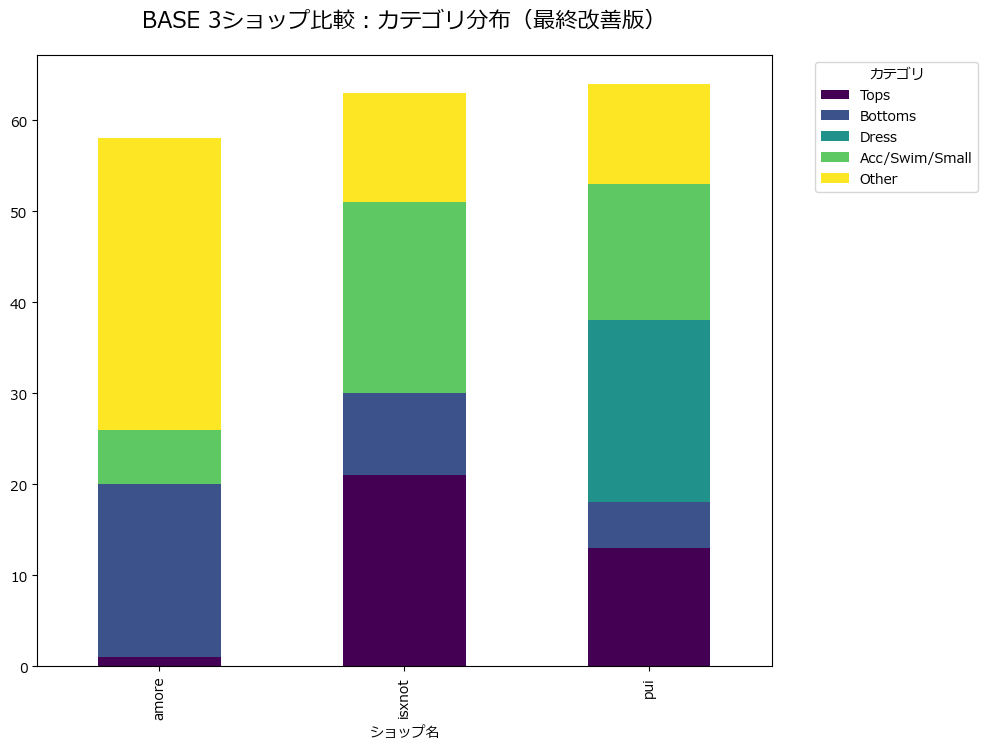

分析対象数: 185件
▼ まだ'Other'に残っている商品
['TRENCH COAT', 'PUI BORDER VINTAGE RED', 'PUI BORDER NEVY', 'SUEDE LONG JACKET', 'HOTEL BENOITE BIG TOTE', 'HOTEL BENOITE TOTE', 'Pui picnic sheet', 'ROSE DE DAMAS アロマティックナチュレソープ', 'LOGO CHARM', 'Emma Cocarne ヘアオイル', 'NOVELTY (THE SUNDAY ROMANTIC)', 'ZIP trench coat', '【サンプル発売】KIMONO jacket', '【サンプル発売】flap shirt', 'ポストカード', 'スマイル切り替えT XS,S,M,L,XL,JS,JM,JL / NRK 26summer', 'サンセットSET XS,S,M,L,XL,JS,JM,JL / NRK 26summer', 'サンドビーニー / NRK 26summer', 'ビーチピグメントT XS,S,M,L,XL,JS,JM,JL / NRK 26summer', 'ベーシックスリットT XS,S,M,L,XL,JS,JM,JL / NRK 26summer', 'ミルキー絞りT XS,S,M,L,XL,JS,JM,JL / NRK 26summer', 'サングルタイガー半袖T FREE(ママパパ用) / MIkki 26summer', 'サングルタイガー半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer', 'サーフィン92半袖T FREE(ママパパ用) / MIkki 26summer', 'サーフィン92半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer', 'RUN半袖T FREE(ママパパ用) / MIkki 26summer', 'RUN半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer', 'スピーディジェリー半袖T FREE(ママパパ用) / MIkki 26summer', 'スピーディジェリー半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer', '24半袖T

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import unicodedata

# 1. データの読み込み
df = pd.read_csv("combined_base_data.csv")

# 【魔法の掃除関数】全角を半角にし、2つ以上のスペースを1つにまとめる
def clean_text(text):
    text = unicodedata.normalize('NFKC', str(text))
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 商品名をきれいに掃除
df['商品名'] = df['商品名'].apply(clean_text)

# 2. 基本のルールベース判定
def infer_category(name):
    name = name.lower()
    if any(k in name for k in ['top', 'tee', 'tシャツ', 'シャツ', 'ブラウス', 'blouse', 'tops', 'ニット', 'カーディガン', 'sweat', 'hoodie', 'outer', 'parker']): return 'Tops'
    if any(k in name for k in ['dress', 'onepiece', 'ワンピース', 'ドレス']): return 'Dress'
    if any(k in name for k in ['pants', 'skirt', 'bottoms', 'パンツ', 'スカート', 'denim', 'ジーンズ', 'レギンス']): return 'Bottoms'
    if any(k in name for k in ['bag', 'accessories', 'ピアス', 'ネックレス', 'バッグ', 'swim', '水着', 'socks', '靴下', 'ring', 'bracelet', 'hat', 'pouch', 'soap', 'スクラブ']): return 'Acc/Swim/Small'
    return 'Other'

df['Category'] = df['商品名'].apply(infer_category)

# 3. AI辞書（掃除後の名前に合わせて最適化）
ai_mapping = {
    "RIBBON KNIT": "Tops", "flower peplum one piece": "Dress", "gingham peplum one piece": "Dress",
    "rose peplum one-piece": "Dress", "Heart peplum one piece": "Dress", "lace camisole": "Tops",
    "PUI HOME ROMPERS": "Bottoms", "THE ROSE BALM": "Acc/Swim/Small", "FLOWRE SETUP": "Dress",
    "red dot one-piece": "Dress", "dot one-piece": "Dress", "CASHMERE KNIT": "Tops",
    "ボーダートップス": "Tops", "flower shirt one-piece": "Dress", "FLOWER ENSEMBLE": "Tops",
    "PUI KIDS HEART ONE PIECE": "Dress", "HOTEL BENOITE SWEAT": "Tops", "CHECK shirt": "Tops",
    "Rib Knit": "Tops", "flap shirt": "Tops", "shelter outer": "Tops", "Cookie snood": "Acc/Swim/Small",
    "HOME": "GOMI", "ABOUT": "GOMI", "Q&A": "GOMI", "BLOG": "GOMI", "CONTACT": "GOMI"
}

df['Category'] = df['商品名'].map(ai_mapping).fillna(df['Category'])
df = df[df['Category'] != 'GOMI']

# 4. 集計と描画
cat_counts = df.groupby(['ショップ名', 'Category']).size().unstack(fill_value=0)
order = ['Tops', 'Bottoms', 'Dress', 'Acc/Swim/Small', 'Other']
cat_counts = cat_counts[[c for c in order if c in cat_counts.columns]]

plt.rcParams['font.family'] = 'Meiryo'
fig, ax = plt.subplots(figsize=(10, 8))
cat_counts.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
plt.title("BASE 3ショップ比較：カテゴリ分布（最終改善版）", fontsize=16, pad=20)
plt.legend(title="カテゴリ", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"分析対象数: {len(df)}件")
print("▼ まだ'Other'に残っている商品")
print(df[df['Category'] == 'Other']['商品名'].unique().tolist())

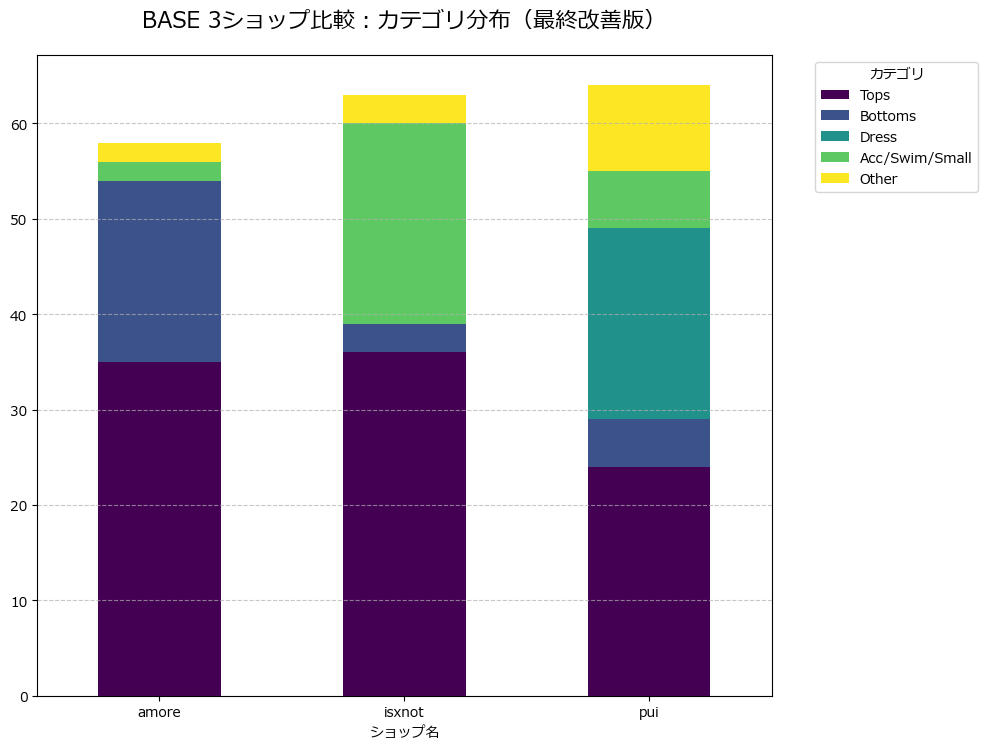

分析対象数: 185件
▼ まだ'Other'に残っている商品
['PUI BORDER VINTAGE RED', 'PUI BORDER NEVY', 'HOTEL BENOITE BIG TOTE', 'HOTEL BENOITE TOTE', 'ROSE DE DAMAS アロマティックナチュレソープ', 'ROSE DE DAMAS オーガニックシュガースクラブ', 'LOGO CHARM', 'Emma Cocarne ヘアオイル', 'NOVELTY (THE SUNDAY ROMANTIC)', 'ポストカード', 'サンドビーニー / NRK 26summer']


In [ ]:
# --- 修正版：分析コード ---
import pandas as pd
import matplotlib.pyplot as plt
import re
import unicodedata

# 1. データの読み込み
df = pd.read_csv("combined_base_data.csv")

# 文字の掃除
def clean_text(text):
    text = unicodedata.normalize('NFKC', str(text))
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['商品名'] = df['商品名'].apply(clean_text)

# 2. 自動判定キーワードの強化
def infer_category(name):
    name = name.lower()
    # 「t」や「トレーナー」をキーワードに追加
    if any(k in name for k in ['top', 'tee', 'tシャツ', 'シャツ', 'ブラウス', 'blouse', 'tops', 'ニット', 'カーディガン', 'sweat', 'hoodie', 'outer', 'parker', 'トレーナー', ' t ']) or name.endswith('t'): 
        return 'Tops'
    if any(k in name for k in ['dress', 'onepiece', 'ワンピース', 'ドレス']): return 'Dress'
    if any(k in name for k in ['pants', 'skirt', 'bottoms', 'パンツ', 'スカート', 'denim', 'ジーンズ', 'レギンス']): return 'Bottoms'
    if any(k in name for k in ['bag', 'accessories', 'ピアス', 'ネックレス', 'バッグ', 'swim', '水着', 'socks', '靴下', 'ring', 'bracelet', 'hat', 'pouch', 'soap']): return 'Acc/Swim/Small'
    return 'Other'

df['Category'] = df['商品名'].apply(infer_category)

# 3. AI辞書（amore のデータを完全復旧）
ai_mapping = {
    # pui
    "RIBBON KNIT": "Tops", "flower peplum one piece": "Dress", "gingham peplum one piece": "Dress",
    "rose peplum one-piece": "Dress", "Heart peplum one piece": "Dress", "lace camisole": "Tops",
    "PUI HOME ROMPERS": "Bottoms", "THE ROSE BALM": "Acc/Swim/Small", "FLOWRE SETUP": "Dress",
    "red dot one-piece": "Dress", "dot one-piece": "Dress", "CASHMERE KNIT": "Tops",
    "ボーダートップス": "Tops", "flower shirt one-piece": "Dress", "FLOWER ENSEMBLE": "Tops",
    "PUI KIDS HEART ONE PIECE": "Dress", "HOTEL BENOITE SWEAT": "Tops", "CHECK shirt": "Tops",
    "Rib Knit": "Tops", "flap shirt": "Tops", "shelter outer": "Tops", "Cookie snood": "Acc/Swim/Small",
    # amore (ここが抜けていました)
    "ランランT XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "レーシングキャットトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "アパートトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "エースT XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "ジャンプトレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "テンダーオープントレーナー XS,S,M,L,XL,JS,JM / Amore 26spring": "Tops",
    "スマイル切り替えT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "サンセットSET XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Acc/Swim/Small",
    "ビーチピグメントT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "ベーシックスリットT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "ミルキー絞りT XS,S,M,L,XL,JS,JM,JL / NRK 26summer": "Tops",
    "サングルタイガー半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "サングルタイガー半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "サーフィン92半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "サーフィン92半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "RUN半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "RUN半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "スピーディジェリー半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "スピーディジェリー半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    "24半袖T FREE(ママパパ用) / MIkki 26summer": "Tops",
    "24半袖T S,M,L,XL,JS,JM,JL / MIkki 26summer": "Tops",
    # サイトノイズ
    "HOME": "GOMI", "ABOUT": "GOMI", "Q&A": "GOMI", "BLOG": "GOMI", "CONTACT": "GOMI"
}

df['Category'] = df['商品名'].map(ai_mapping).fillna(df['Category'])
df = df[df['Category'] != 'GOMI']

# 4. 集計と描画
cat_counts = df.groupby(['ショップ名', 'Category']).size().unstack(fill_value=0)
order = ['Tops', 'Bottoms', 'Dress', 'Acc/Swim/Small', 'Other']
cat_counts = cat_counts[[c for c in order if c in cat_counts.columns]]

plt.rcParams['font.family'] = 'Meiryo'
fig, ax = plt.subplots(figsize=(10, 8))
cat_counts.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

# --- ここに修正を追加 ---
plt.xticks(rotation=0)  # ショップ名を横書きにする
plt.grid(axis='y', linestyle='--', alpha=0.7)  # 横の点線を入れる
# ----------------------

plt.title("BASE 3ショップ比較：カテゴリ分布（最終改善版）", fontsize=16, pad=20)
plt.legend(title="カテゴリ", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
# 【これを追加】画像を保存する（ファイル名は自由に変えてOKです）
plt.savefig("base_shop_comparison_final.png", dpi=300)
plt.show()

print(f"分析対象数: {len(df)}件")
print("▼ まだ'Other'に残っている商品")
print(df[df['Category'] == 'Other']['商品名'].unique().tolist())